# qrc-engine Evaluation

This notebook exercises the `qrc-engine` API end to end on two standard reservoir-computing tasks.
It uses the same unified `Reservoir` workflow across three backend families: gate-based, photonic, and open-system.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from qrc_engine import Reservoir
from qrc_engine.backends import DynamiqsBackend, PercevalBackend, QiskitBackend
from qrc_engine.tasks import mackey_glass, narma10
from qrc_engine.utils import nrmse

warnings.filterwarnings('ignore', module='perceval.utils.persistent_data')
plt.style.use('seaborn-v0_8-whitegrid')

## NARMA-10 Benchmark

The benchmark below uses tuned but fixed hyperparameters per backend. The point is not to win a leaderboard, but to show that the same fit/predict loop runs cleanly across different quantum paradigms.

Backend           | Washout | Alpha   | NRMSE
------------------|---------|---------|-------
Qiskit (3q, d3)   | 50      | 1e-02   | 0.7410
Perceval (5m)     | 75      | 1e-01   | 0.9290
dynamiqs (4lvl)   | 50      | 1e-04   | 0.6741


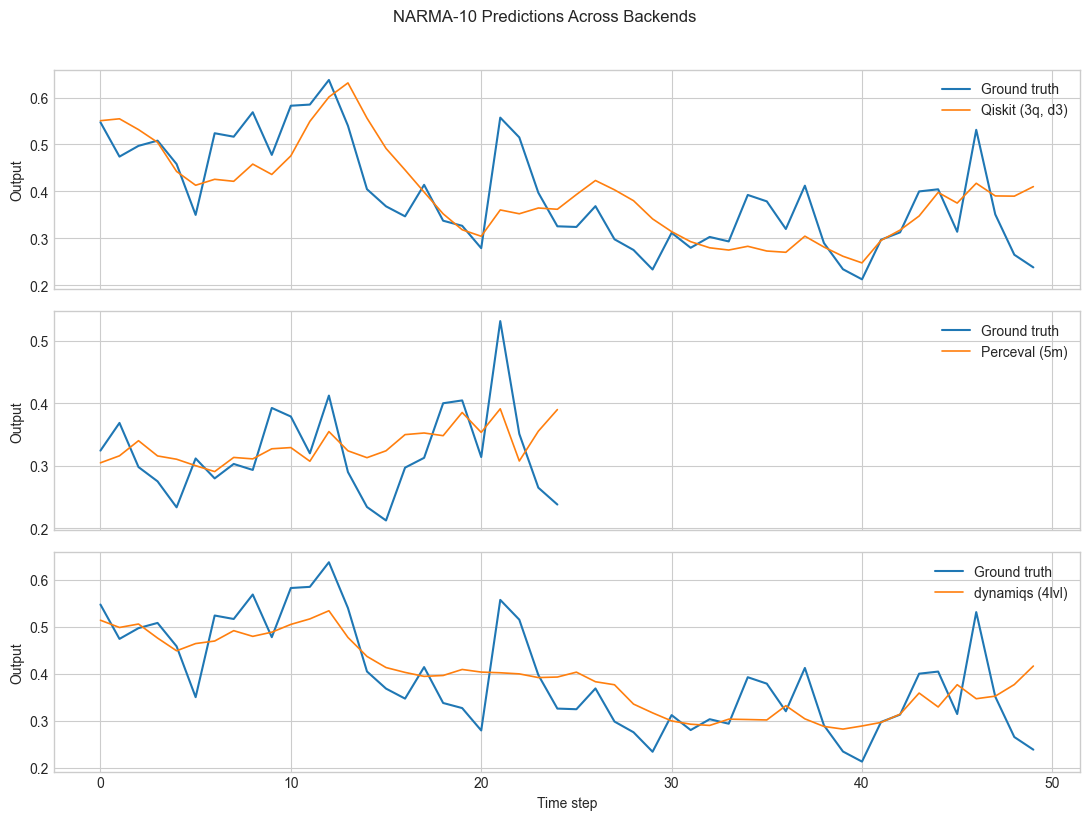

In [2]:
X_train, y_train, X_test, y_test = narma10(n_samples=500, split=0.8, seed=11)

configs = [
    ('Qiskit (3q, d3)', {'washout': 50, 'alpha': 1e-2}, QiskitBackend(n_qubits=3, depth=3, seed=11)),
    ('Perceval (5m)', {'washout': 75, 'alpha': 1e-1}, PercevalBackend(n_modes=5, n_photons=2, depth=2, seed=3)),
    ('dynamiqs (4lvl)', {'washout': 50, 'alpha': 1e-4}, DynamiqsBackend(levels=4, dt=0.4, gamma=0.06, seed=3)),
]

def evaluate_backend(label, config, backend):
    reservoir = Reservoir(backend=backend, washout=config['washout'], alpha=config['alpha'])
    reservoir.fit(X_train, y_train)
    predictions = reservoir.predict(X_test)
    score = nrmse(y_test[config['washout']:], predictions)
    return reservoir, predictions, score

results = []
figure, axes = plt.subplots(len(configs), 1, figsize=(11, 8), sharex=True)
for axis, (label, config, backend) in zip(np.atleast_1d(axes), configs):
    reservoir, predictions, score = evaluate_backend(label, config, backend)
    results.append((label, config, score))
    axis.plot(y_test[config['washout']:], label='Ground truth', linewidth=1.5)
    axis.plot(predictions, label=label, linewidth=1.2)
    axis.set_ylabel('Output')
    axis.legend(loc='upper right')
axes[-1].set_xlabel('Time step')
figure.suptitle('NARMA-10 Predictions Across Backends', y=1.02)
figure.tight_layout()

print('Backend           | Washout | Alpha   | NRMSE')
print('------------------|---------|---------|-------')
for label, config, score in results:
    print(f"{label:<18}| {config['washout']:<7} | {config['alpha']:<7.0e} | {score:0.4f}")


## Mackey-Glass Forecasting

A second task checks that the same API can handle a chaotic one-step-ahead forecasting problem.

Mackey-Glass NRMSE: 0.4141


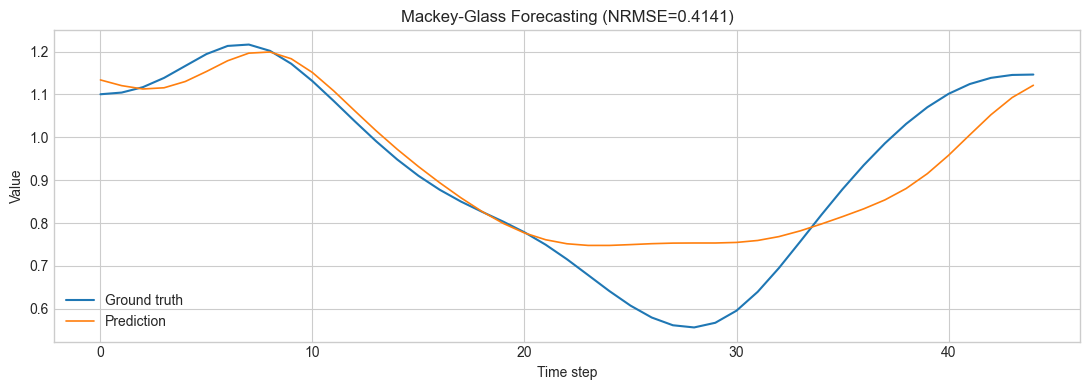

In [3]:
X_train, y_train, X_test, y_test = mackey_glass(n_samples=600, split=0.8, seed=5)
backend = DynamiqsBackend(levels=4, dt=0.4, gamma=0.06, seed=3)
reservoir = Reservoir(backend=backend, washout=75, alpha=1e-4)
reservoir.fit(X_train, y_train)
predictions = reservoir.predict(X_test)
score = nrmse(y_test[75:], predictions)

plt.figure(figsize=(11, 4))
plt.plot(y_test[75:], label='Ground truth', linewidth=1.5)
plt.plot(predictions, label='Prediction', linewidth=1.2)
plt.title(f'Mackey-Glass Forecasting (NRMSE={score:0.4f})')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
print(f'Mackey-Glass NRMSE: {score:0.4f}')

## Takeaways

- The user-facing API stays fixed while the backend changes.
- Backends expose different internal physics, but all return fixed-width state vectors for the same readout pipeline.
- The benchmark configuration is deterministic, making it suitable for regression testing and portfolio review.